# 01 — Sales Overview
Key sales KPIs across the entire dataset: total revenue, orders, average order value, and monthly trends.


In [17]:
from pyhive import hive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# ── Global style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("muted")

def get_conn():
    return hive.connect(host="hive-server2", port=10000,
                        database="default", auth="NONE")

def fetch_df(cur, sql):
    cur.execute(sql)
    cols = [d[0].split(".")[-1] for d in cur.description]
    return pd.DataFrame(cur.fetchall(), columns=cols)

def fmt_usd(v):
    if abs(v) >= 1_000_000:
        return f"${v/1_000_000:.2f}M"
    if abs(v) >= 1_000:
        return f"${v/1_000:.1f}K"
    return f"${v:.0f}"

conn = get_conn()
cur  = conn.cursor()
print("Connected.")


Connected.


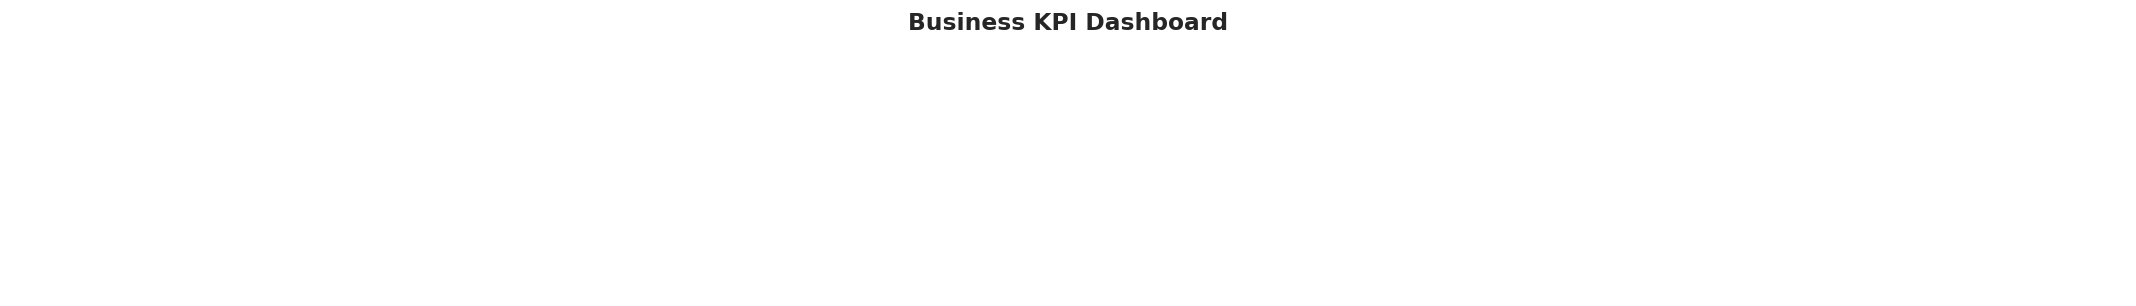

In [18]:
# ── KPI Summary ───────────────────────────────────────────────────────────────
kpi = fetch_df(cur, """
    SELECT
        COUNT(DISTINCT o.order_id)                   AS total_orders,
        COUNT(DISTINCT o.customer_id)                AS total_customers,
        ROUND(SUM(oi.sales), 2)                      AS total_revenue,
        ROUND(AVG(oi.sales), 2)                      AS avg_item_sales,
        ROUND(SUM(oi.profit), 2)                     AS total_profit,
        ROUND(SUM(oi.profit)/SUM(oi.sales)*100, 2)  AS profit_margin_pct
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
""")

row = kpi.iloc[0]
kpis = [
    ("Total Orders",     f"{int(row.total_orders):,}",    "#4C72B0"),
    ("Unique Customers", f"{int(row.total_customers):,}", "#DD8452"),
    ("Total Revenue",    fmt_usd(row.total_revenue),      "#55A868"),
    ("Total Profit",     fmt_usd(row.total_profit),       "#C44E52"),
    ("Avg Line Sales",   fmt_usd(row.avg_item_sales),     "#937860"),
    ("Profit Margin",    f"{row.profit_margin_pct:.1f}%", "#8172B2"),
]

fig, axes = plt.subplots(1, 6, figsize=(18, 2.5))
fig.suptitle("Business KPI Dashboard", fontsize=14, fontweight="bold", y=1.02)
for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.axis("off")
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=18,
            fontweight="bold", color="white", transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha="center", va="center", fontsize=9,
            color="white", transform=ax.transAxes, alpha=0.9)
plt.tight_layout()
plt.show()


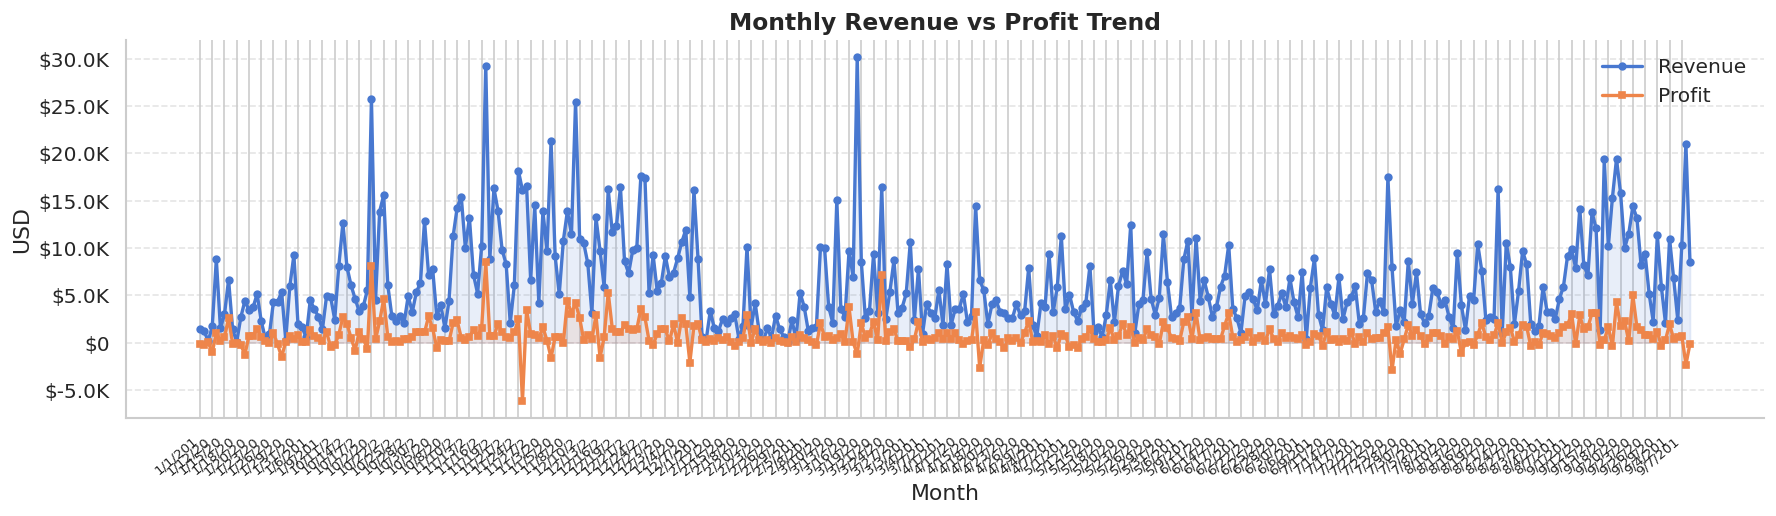

In [19]:
# ── Monthly Sales Trend ───────────────────────────────────────────────────────
monthly = fetch_df(cur, """
    SELECT SUBSTR(o.order_date,1,7) AS month,
           ROUND(SUM(oi.sales),2)   AS revenue,
           ROUND(SUM(oi.profit),2)  AS profit
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY SUBSTR(o.order_date,1,7)
    ORDER BY month
""")

tick_positions = list(range(0, len(monthly), 3))
tick_labels    = [monthly["month"].iloc[i] for i in tick_positions]

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.fill_between(range(len(monthly)), monthly["revenue"],
                alpha=0.12, color=PALETTE[0])
ax.plot(range(len(monthly)), monthly["revenue"], marker="o", markersize=4,
        color=PALETTE[0], linewidth=2, label="Revenue")
ax.fill_between(range(len(monthly)), monthly["profit"],
                alpha=0.12, color=PALETTE[1])
ax.plot(range(len(monthly)), monthly["profit"], marker="s", markersize=4,
        color=PALETTE[1], linewidth=2, label="Profit")
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=40, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_usd(x)))
ax.set_title("Monthly Revenue vs Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("USD")
ax.legend(frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


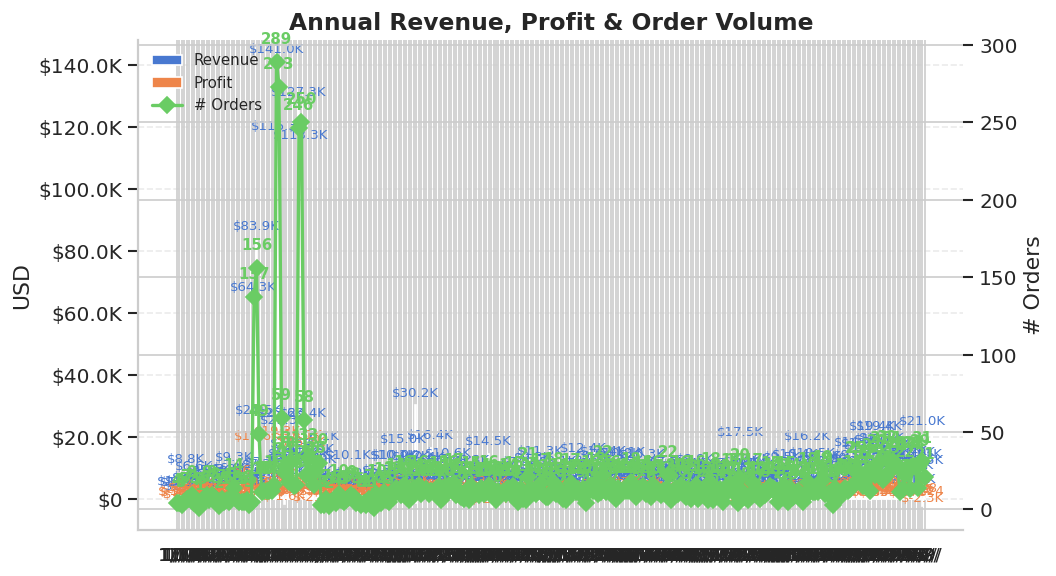

In [20]:
# ── Annual Sales by Year ──────────────────────────────────────────────────────
yearly = fetch_df(cur, """
    SELECT SUBSTR(o.order_date,1,4) AS year,
           ROUND(SUM(oi.sales),2)     AS revenue,
           ROUND(SUM(oi.profit),2)    AS profit,
           COUNT(DISTINCT o.order_id) AS orders
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY SUBSTR(o.order_date,1,4)
    ORDER BY year
""")

bar_width = 0.35
x         = range(len(yearly))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

bars1 = ax1.bar([i - bar_width/2 for i in x], yearly["revenue"],
                bar_width, color=PALETTE[0], label="Revenue", zorder=3)
bars2 = ax1.bar([i + bar_width/2 for i in x], yearly["profit"],
                bar_width, color=PALETTE[1], label="Profit",  zorder=3)
ax2.plot(x, yearly["orders"], color=PALETTE[2], marker="D",
         linewidth=2, markersize=7, label="# Orders", zorder=4)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2000,
             fmt_usd(bar.get_height()),
             ha="center", va="bottom", fontsize=8, color=PALETTE[0])

for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             fmt_usd(bar.get_height()),
             ha="center", va="bottom", fontsize=8, color=PALETTE[1])

for xi, yi in zip(x, yearly["orders"]):
    ax2.text(xi, yi + 10, str(int(yi)),
             ha="center", va="bottom", fontsize=9,
             color=PALETTE[2], fontweight="bold")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2,
           loc="upper left", frameon=False, fontsize=9)

ax1.set_xticks(list(x))
ax1.set_xticklabels(yearly["year"], fontsize=11)
ax1.set_title("Annual Revenue, Profit & Order Volume")
ax1.set_ylabel("USD")
ax2.set_ylabel("# Orders")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()


In [ ]:
cur.close()
conn.close()
print("Done.")
